# Hydrogen fuel-cell aircraft

A pure fuel-cell electric powertrain with a cryogenic LH2 tank — no battery, no gas
turbine. We also re-fly the mission with the tank thermodynamics tracked, to see the
tank pressure / mass / venting evolve. (Requires CoolProp for the tank.)

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from common import hydrogen_config

## Build the design specification

`tank=True` attaches a cryogenic LH2 tank. Try changing the design cell voltage.

In [2]:
config = hydrogen_config(v_cell_design=0.5, tank=True)
print('configuration :', config.configuration)
print('Ef (H2 LHV)   :', config.energy.Ef/1e6, 'MJ/kg')

configuration : Hydrogen
Ef (H2 LHV)   : 120.0 MJ/kg


## Size the aircraft and read the results

In [3]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
fc = aircraft.fuelcell
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'usable H2       : {aircraft.weight.WH2_Fuel:8.1f} kg')
print(f'fuel-cell mass  : {r.WPT:8.1f} kg  ({fc.N_cells} cells)')
print(f'tank empty mass : {aircraft.weight.WTank:8.1f} kg')

take-off weight :  30436.7 kg
usable H2       :    591.8 kg
fuel-cell mass  :   5951.0 kg  (2000 cells)
tank empty mass :    894.0 kg


## Plot the design outcomes

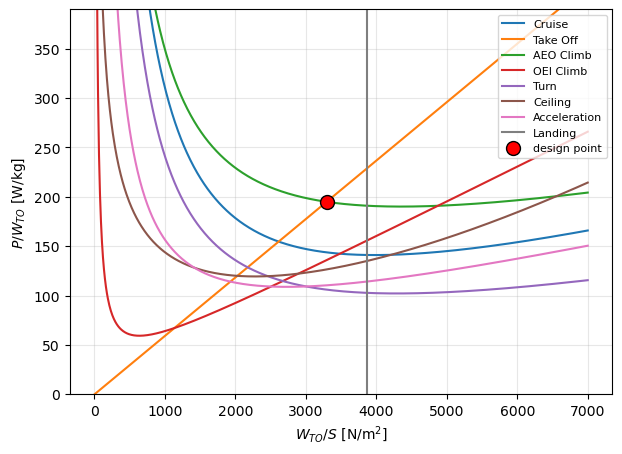

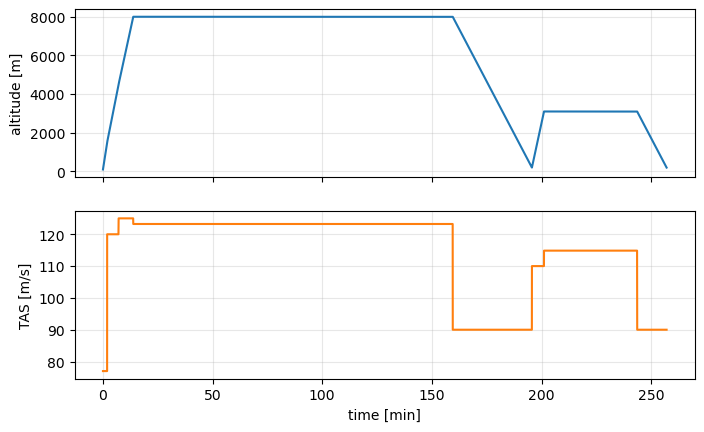

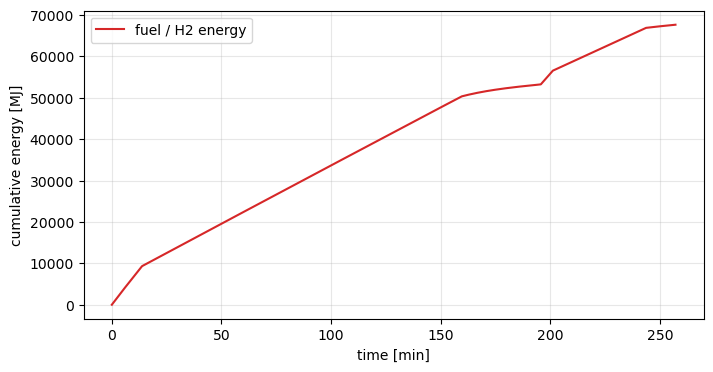

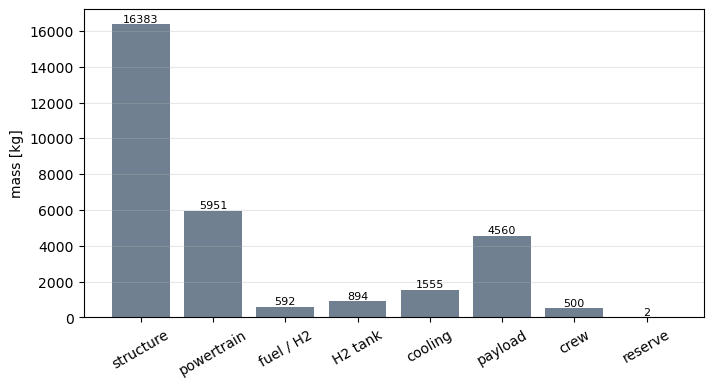

In [4]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()


## Tank thermodynamics over the mission

Switch on tank tracking and re-fly the mission, then plot the tank state.

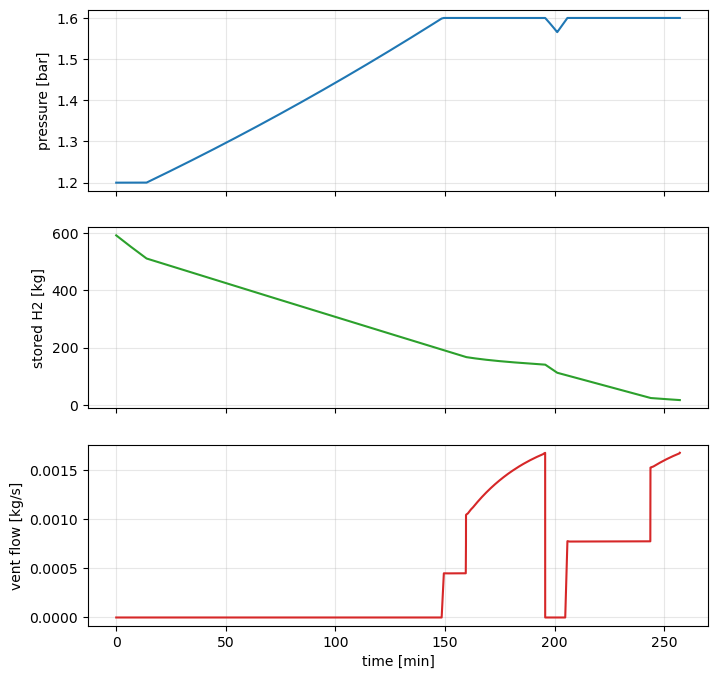

In [5]:
aircraft.mission.track_tank = True
aircraft.mission.EvaluateMission(aircraft.weight.WTO)
pp.plot_tank_state(aircraft); plt.show()